# Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load Dataset from GitHub

In [ ]:
github_url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML-Svl/refs/heads/main/dataset/diabetes%20(1).csv"

df = pd.read_csv(github_url)

# Display Dataset

In [ ]:
print("First 5 Rows of Dataset:\n")
print(df.head())

First 5 Rows of Dataset:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Dataset Information

In [ ]:
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


# Check Missing Values


In [ ]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# Dataset target column = Outcome


In [ ]:
target_column = 'Outcome'

# Separate Features (X) and Target (y)

In [ ]:
X = df.drop(target_column, axis=1)
y = df[target_column]

# Target Distribution

In [8]:
target_names = ['No Diabetes', 'Diabetes']

print("\nTarget Distribution:\n")
print(y.value_counts())

print("\nClass Balance:")

for i, name in enumerate(target_names):

    count = (y == i).sum()

    percentage = (count / len(y)) * 100

    print(f"{name}: {count} ({percentage:.2f}%)")



Target Distribution:

Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
No Diabetes: 500 (65.10%)
Diabetes: 268 (34.90%)


# Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 614
Testing Samples: 154


# Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f"\nMean of scaled training data: {X_train_scaled.mean():.6f}")

print(f"Std of scaled training data: {X_train_scaled.std():.6f}")


Mean of scaled training data: -0.000000
Std of scaled training data: 1.000000


# Elbow Method - Finding Optimal K

In [11]:
k_range = range(1, 31)

train_accuracies = []
test_accuracies = []
error_rates = []

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    train_acc = knn.score(X_train_scaled, y_train)

    test_acc = knn.score(X_test_scaled, y_test)

    train_accuracies.append(train_acc)

    test_accuracies.append(test_acc)

    error_rates.append(1 - test_acc)

# Find Optimal K

In [12]:
optimal_k_idx = np.argmax(test_accuracies)

optimal_k = list(k_range)[optimal_k_idx]

print(f"\nOptimal K: {optimal_k}")

print(f"Best Test Accuracy: {test_accuracies[optimal_k_idx]:.4f}")



Optimal K: 12
Best Test Accuracy: 0.7727


# Plot Accuracy and Error Rate

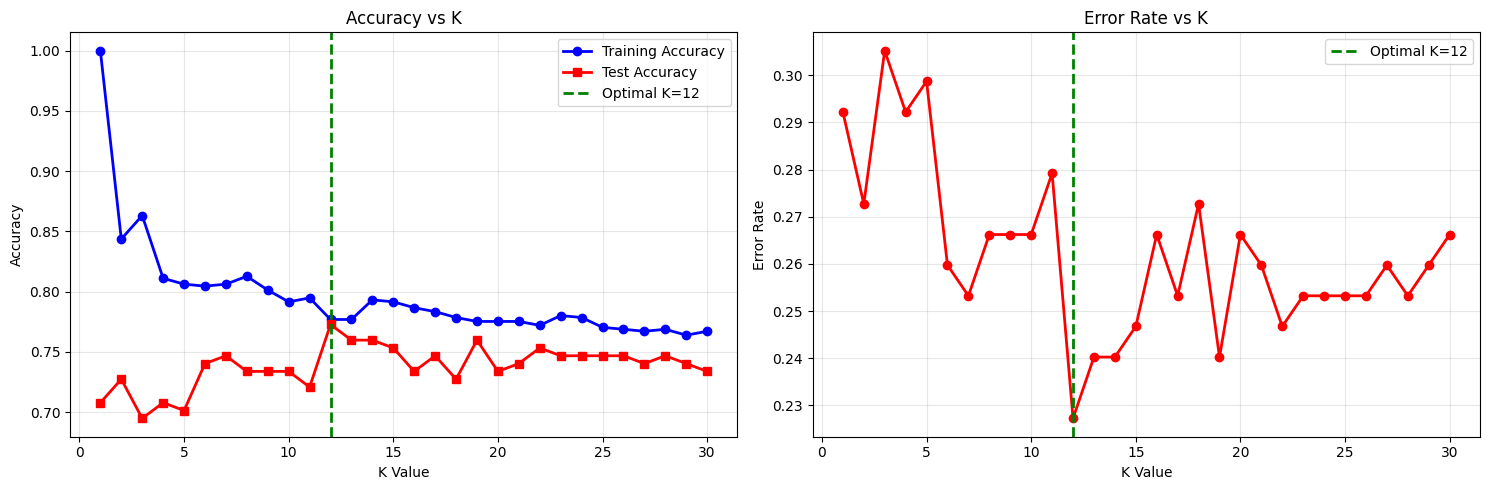

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot

axes[0].plot(
    k_range,
    train_accuracies,
    'b-o',
    label='Training Accuracy',
    linewidth=2
)

axes[0].plot(
    k_range,
    test_accuracies,
    'r-s',
    label='Test Accuracy',
    linewidth=2
)

axes[0].axvline(
    x=optimal_k,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Optimal K={optimal_k}'
)

axes[0].set_xlabel('K Value')

axes[0].set_ylabel('Accuracy')

axes[0].set_title('Accuracy vs K')

axes[0].legend()

axes[0].grid(alpha=0.3)

# Error Rate Plot

axes[1].plot(
    k_range,
    error_rates,
    'ro-',
    linewidth=2
)

axes[1].axvline(
    x=optimal_k,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Optimal K={optimal_k}'
)

axes[1].set_xlabel('K Value')

axes[1].set_ylabel('Error Rate')

axes[1].set_title('Error Rate vs K')

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Hyperparameter Tuning using GridSearchCV

In [14]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 84 candidates, totalling 420 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13, 15], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

# Best Parameters

In [15]:
print("\nGrid Search Completed!")

print("\nBest Parameters:")

for param, value in grid_search.best_params_.items():

    print(f"{param}: {value}")

print(f"\nBest Cross Validation Accuracy: {grid_search.best_score_:.4f}")


Grid Search Completed!

Best Parameters:
metric: manhattan
n_neighbors: 15
p: 1
weights: uniform

Best Cross Validation Accuracy: 0.7688


# Best Model

In [16]:
best_knn = grid_search.best_estimator_

best_knn.fit(X_train_scaled, y_train)

print("\nBest KNN Model:\n")

print(best_knn)


Best KNN Model:

KNeighborsClassifier(metric='manhattan', n_neighbors=15, p=1)


# Predictions

In [17]:
y_pred = best_knn.predict(X_test_scaled)

y_pred_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics

In [18]:
test_accuracy = accuracy_score(y_test, y_pred)

test_precision = precision_score(y_test, y_pred)

test_recall = recall_score(y_test, y_pred)

test_f1 = f1_score(y_test, y_pred)

test_auc = roc_auc_score(y_test, y_pred_proba)

print("\nEvaluation Metrics:\n")

print(f"Accuracy  : {test_accuracy:.4f}")

print(f"Precision : {test_precision:.4f}")

print(f"Recall    : {test_recall:.4f}")

print(f"F1 Score  : {test_f1:.4f}")

print(f"AUC Score : {test_auc:.4f}")


Evaluation Metrics:

Accuracy  : 0.7727
Precision : 0.7209
Recall    : 0.5741
F1 Score  : 0.6392
AUC Score : 0.8060


# Classification Report

In [19]:
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.79      0.88      0.83       100
    Diabetes       0.72      0.57      0.64        54

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



# Confusion Matrix

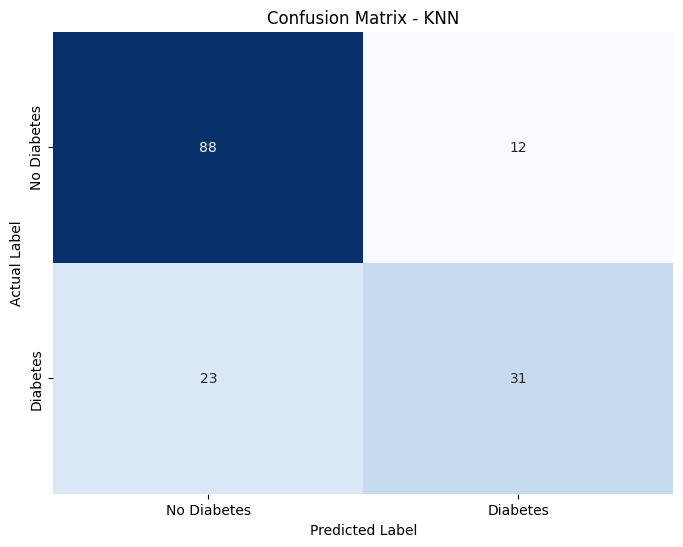

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Confusion Matrix - KNN')

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

# ROC Curve

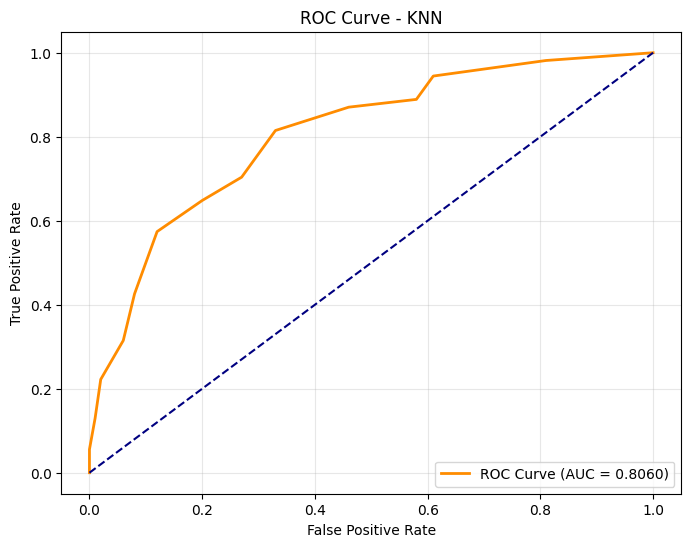

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve - KNN')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.show()

# 2D Decision Boundary Visualization

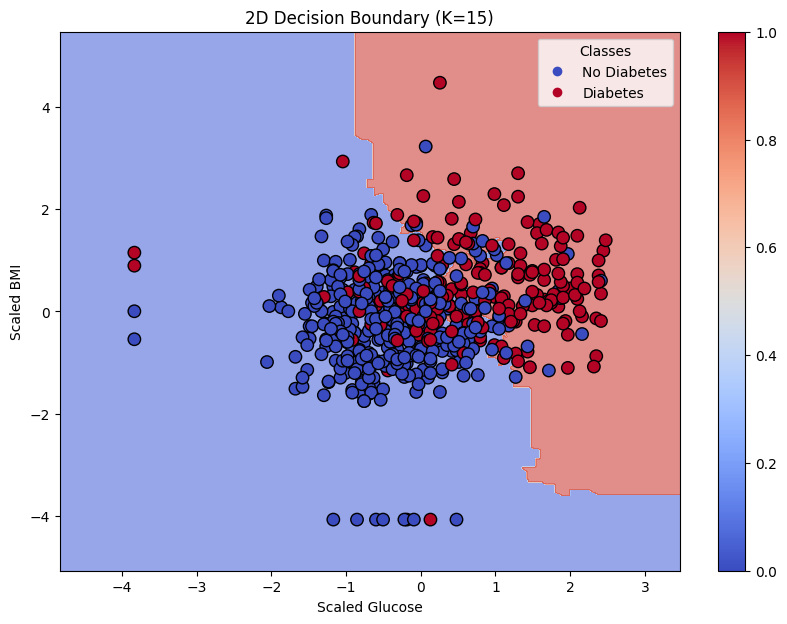

In [22]:
features_2D = ['Glucose', 'BMI']

X_2D = df[features_2D]

y_2D = df[target_column]

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)

scaler_2D = StandardScaler()

X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)

X_test_2D_scaled = scaler_2D.transform(X_test_2D)

knn_2D = KNeighborsClassifier(
    n_neighbors=best_knn.n_neighbors,
    weights=best_knn.weights,
    metric=best_knn.metric
)

knn_2D.fit(X_train_2D_scaled, y_train_2D)

# Mesh Grid

h = 0.02

x_min, x_max = (
    X_train_2D_scaled[:, 0].min() - 1,
    X_train_2D_scaled[:, 0].max() + 1
)

y_min, y_max = (
    X_train_2D_scaled[:, 1].min() - 1,
    X_train_2D_scaled[:, 1].max() + 1
)

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_2D.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.coolwarm)

scatter = plt.scatter(
    X_train_2D_scaled[:, 0],
    X_train_2D_scaled[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    s=80
)

handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    target_names,
    title="Classes"
)

plt.xlabel(f'Scaled {features_2D[0]}')

plt.ylabel(f'Scaled {features_2D[1]}')

plt.title(
    f'2D Decision Boundary (K={best_knn.n_neighbors})'
)

plt.colorbar(scatter)

plt.show()

# Sample Predictions

In [23]:
predictions_df = pd.DataFrame({
    'Actual_Class': y_test.values,
    'Predicted_Class': y_pred,
    'Actual_Name': [target_names[i] for i in y_test.values],
    'Predicted_Name': [target_names[i] for i in y_pred],
    'Probability_No_Diabetes': best_knn.predict_proba(X_test_scaled)[:, 0],
    'Probability_Diabetes': best_knn.predict_proba(X_test_scaled)[:, 1],
    'Correct': y_test.values == y_pred
})

print("\nSample Predictions:\n")

print(predictions_df.head(15).to_string(index=False))


Sample Predictions:

 Actual_Class  Predicted_Class Actual_Name Predicted_Name  Probability_No_Diabetes  Probability_Diabetes  Correct
            0                1 No Diabetes       Diabetes                 0.333333              0.666667    False
            0                0 No Diabetes    No Diabetes                 0.800000              0.200000     True
            0                0 No Diabetes    No Diabetes                 0.800000              0.200000     True
            1                0    Diabetes    No Diabetes                 0.666667              0.333333    False
            0                0 No Diabetes    No Diabetes                 0.800000              0.200000     True
            0                0 No Diabetes    No Diabetes                 0.933333              0.066667     True
            1                0    Diabetes    No Diabetes                 0.666667              0.333333    False
            1                1    Diabetes       Diabetes         

# Final Accuracy

In [24]:
correct_predictions = (y_test == y_pred).sum()

total_predictions = len(y_test)

print(
    f"\nCorrect Predictions: "
    f"{correct_predictions}/{total_predictions}"
)

print(
    f"Final Accuracy: "
    f"{(correct_predictions/total_predictions)*100:.2f}%"
)


Correct Predictions: 119/154
Final Accuracy: 77.27%


# End of Project

In [25]:
print("\nKNN Diabetes Classification Project Completed Successfully!")


KNN Diabetes Classification Project Completed Successfully!
